In [1]:
from fourinarowfunctions import *

filename = '../data/trialdata.csv'
data_dict = load_data(filename, verbose = False)
parsed_dict = {}
for username, data in data_dict.items():
    try:
        parsed_dict[username] = get_parsed_data(data, username, include_practice = False)
    except AssertionError as e:
        # print(f"Incomplete {username}: {e}")
        continue
usernames = parsed_dict.keys()
print(f"{len(usernames)} users with complete data")

user 187:R_3oHOHstFKN4HiLA started 34 games.
user 250:R_r2BwOdT2hnmQ5WN started 34 games.
user A242:R_ymscU32j53VKwil started 70 games.
user A1157:R_0GqMhnxN1UuSyZP started 34 games.
user 883:R_b255PQj1bstkMjD started 34 games.
159 users with complete data


In [2]:
"  ".join(sorted(usernames))

'101:R_31SM3mwQvAhBwar  102:R_vdABJ1XvXNriwff  107:R_2ahKzS67s2u094R  117:R_2XpQzVOPaMJjkCo  121:R_2zoxitKzRuYUblm  129:R_2q8z9DfvMUHDZio  137:R_2X1ycnpBX7zJOwI  139:R_1F5MGuZ2rKZOLnc  149:R_shhEOP9BPIFkz97  150:R_3ilNhJufw9u0JJr  152:R_XEQd4AtPvWuAWnT  156:R_2TTetTXWqRwQOGb  166:R_9Nac2hjg6u7BlS1  171:R_1Qck2ykGDls2DLz  175:R_2vjnTMhG0Bpa7wq  179:R_2xV1IwgJyplwuvp  180:R_1OGFPUUh0z8rWBh  181:R_3fDgQlApbcv1n4e  182:R_3NEgCFlK1BFSmdZ  183:R_2uPQbPniskmS0Ep  187:R_3oHOHstFKN4HiLA  192:R_1LeQOpZ9pat1k7D  194:R_24rdiskqYQc7BsO  196:R_0voL9dLPRpILrS9  197:R_bqny5leXGykyp0t  199:R_D1Afhly6eOCY66B  200:R_1NCzjmN3Hl5r3HF  201:R_3kzZPXnjFGbpt30  202:R_2OHMsGSLXJZG0Bc  208:R_2AST2XkjQUqflkc  209:R_1esokoelkIOTy89  212:R_OOl4OrOpRgbrLBD  215:R_32R47f1GRrLhRdX  216:R_21j62EoiJ63yEJ5  217:R_1JPc2llYzw1ezqs  221:R_2wvlbfkxX6e4M29  226:R_2X10rcLujzFpHxv  227:R_2qlLx30lmNEXUJL  228:R_ULyuWg2JwZBuGiJ  229:R_3KxYOzYEKloODvs  230:R_28G5rUmynDONqbJ  231:R_2QRpawEy8w6txvN  236:R_24qFUPTZKx0SybQ  242:R_12lQ

In [3]:
def show_game(subject, game_nr):
    for state in parsed_dict[subject][game_nr]:
        show_board(state["bp"], state["wp"], state["tile"], state["user_color"])

def add_animation(writer, ax, game):
    for state in game:
        ax.clear()
        draw_board(state["bp"], state["wp"], None, state["user_color"], ax)
        writer.grab_frame()
        draw_board(state["bp"], state["wp"], state["tile"], state["user_color"], ax)
        writer.grab_frame()
    winner = get_parsed_outcome(game)
    winner_text = "Player won" if winner > 0 else "Opponent won (next move)" if winner < 0 else "Draw"
    ax.text(0.0, 0.0, winner_text, fontsize=24, color="darkred", ha="left", va="center")
    writer.grab_frame()
    writer.grab_frame()

import matplotlib.animation as animation

def save_animation(filename, game_list):
    writer = animation.FFMpegWriter(fps=2, codec="libx264")
    output_file = filename
    # Open the writer using a persistent figure object
    ax = get_ax()
    with writer.saving(ax.get_figure(), output_file, dpi=100):  # Link this figure to the writer
        for i, game in enumerate(game_list):
            add_animation(writer, ax, game)
            print(f"Added game {i+1} of {len(game_list)}", end='\r')
        for _ in range(5):  # Add identical frames to hold the last frame
            writer.grab_frame()
    print(f"Done writing {filename}")

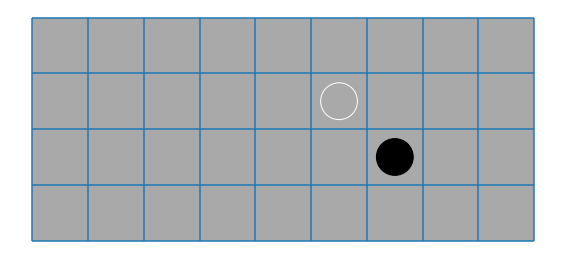

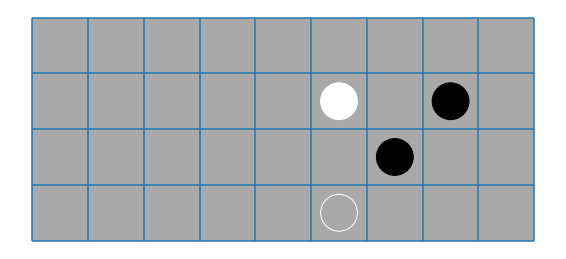

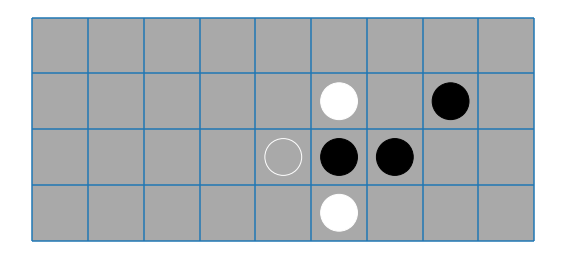

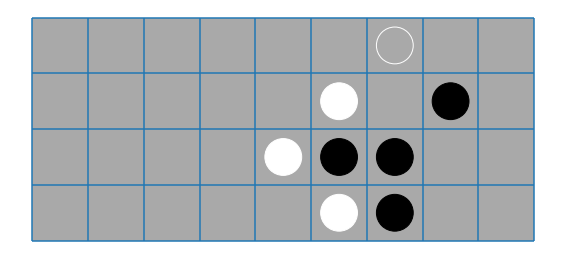

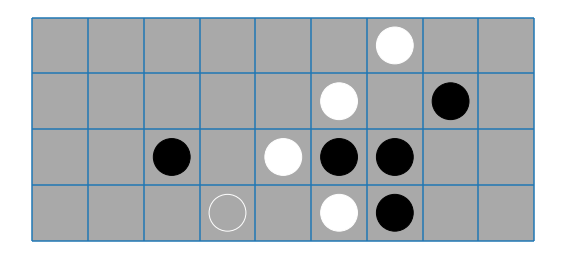

In [4]:
# show_game('200:R_1NCzjmN3Hl5r3HF', 25) # age bin 0
# show_game('117:R_2XpQzVOPaMJjkCo', 25) # age bin 1
show_game('A1099:R_xrAaD53OJwbsqch', 25) # age bin 2

Done writing No Tree Best game A314_R_1mfw4bW019u3R2s.mp4
Done writing No Tree Worst game 250_R_r2BwOdT2hnmQ5WN.mp4
Done writing No Tree Best overall 236_R_24qFUPTZKx0SybQ.mp4
Done writing No Tree Worst overall 878_R_1oj3N9paNMQNcBO.mp4


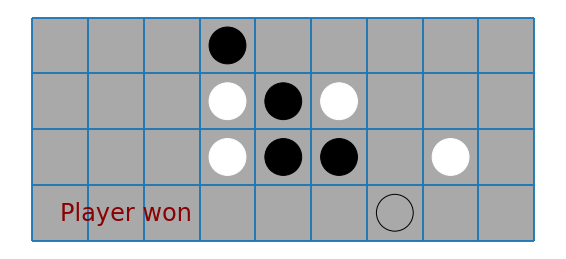

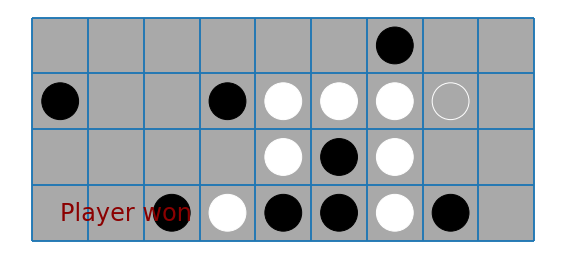

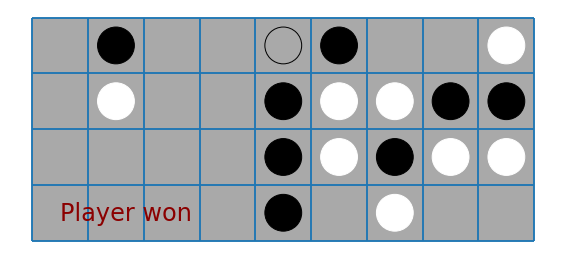

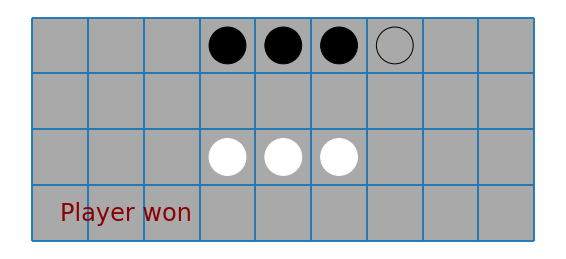

In [5]:
save_animation("No Tree Best game A314_R_1mfw4bW019u3R2s.mp4", parsed_dict["A314:R_1mfw4bW019u3R2s"])
save_animation("No Tree Worst game 250_R_r2BwOdT2hnmQ5WN.mp4", parsed_dict["250:R_r2BwOdT2hnmQ5WN"])

save_animation("No Tree Best overall 236_R_24qFUPTZKx0SybQ.mp4", parsed_dict["236:R_24qFUPTZKx0SybQ"])
save_animation("No Tree Worst overall 878_R_1oj3N9paNMQNcBO.mp4", parsed_dict["878:R_1oj3N9paNMQNcBO"])